# 00_dataset_setup
- [kaggle - Powerlifting Database](https://www.kaggle.com/datasets/open-powerlifting/powerlifting-database/data)
- 데이터셋 다운로드 후, dataset 폴더 안에 수동 저장

In [1]:
import pandas as pd

file_path = "./dataset/openpowerlifting-2024-01-06-4c732975.csv"

df = pd.read_csv(file_path, encoding="ISO-8859-1", sep=",", on_bad_lines="skip")


C:\Users\DaeHyun\AppData\Local\Temp\ipykernel_7684\1462235452.py:5: DtypeWarning: Columns (31,33,35,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding="ISO-8859-1", sep=",", on_bad_lines="skip")


In [2]:
df.head()

,Name,Sex,Event,Equipment,Age,AgeClass,BirthYearClass,Division,BodyweightKg,WeightClassKg,...,Tested,Country,State,Federation,ParentFederation,Date,MeetCountry,MeetState,MeetTown,MeetName
0,Alona Vladi,F,SBD,Raw,33.0,24-34,24-39,O,58.30,60,...,Yes,Russia,NaN,GFP,NaN,2019-05-11,Russia,NaN,Bryansk,Open Tournament
1,Galina Solovyanova,F,SBD,Raw,43.0,40-44,40-49,M1,73.10,75,...,Yes,Russia,NaN,GFP,NaN,2019-05-11,Russia,NaN,Bryansk,Open Tournament
2,Daniil Voronin,M,SBD,Raw,15.5,16-17,14-18,T,67.40,75,...,Yes,Russia,NaN,GFP,NaN,2019-05-11,Russia,NaN,Bryansk,Open Tournament
3,Aleksey Krasov,M,SBD,Raw,35.0,35-39,24-39,O,66.65,75,...,Yes,Russia,NaN,GFP,NaN,2019-05-11,Russia,NaN,Bryansk,Open Tournament
4,Margarita Pleschenkova,M,SBD,Raw,26.5,24-34,24-39,O,72.45,75,...,Yes,Russia,NaN,GFP,NaN,2019-05-11,Russia,NaN,Bryansk,Open Tournament


In [3]:
# 도핑 테스트를 수행한 인원만 추출
# SBD : 스쿼트, 벤치프레스, 데드리프트를 모두 수행한 인원만 추출
tested_df = df[(df["Tested"] == "Yes") & (df["Event"] == "SBD")]

In [4]:
tested_df.head()

,Name,Sex,Event,Equipment,Age,AgeClass,BirthYearClass,Division,BodyweightKg,WeightClassKg,...,Tested,Country,State,Federation,ParentFederation,Date,MeetCountry,MeetState,MeetTown,MeetName
0,Alona Vladi,F,SBD,Raw,33.0,24-34,24-39,O,58.30,60,...,Yes,Russia,NaN,GFP,NaN,2019-05-11,Russia,NaN,Bryansk,Open Tournament
1,Galina Solovyanova,F,SBD,Raw,43.0,40-44,40-49,M1,73.10,75,...,Yes,Russia,NaN,GFP,NaN,2019-05-11,Russia,NaN,Bryansk,Open Tournament
2,Daniil Voronin,M,SBD,Raw,15.5,16-17,14-18,T,67.40,75,...,Yes,Russia,NaN,GFP,NaN,2019-05-11,Russia,NaN,Bryansk,Open Tournament
3,Aleksey Krasov,M,SBD,Raw,35.0,35-39,24-39,O,66.65,75,...,Yes,Russia,NaN,GFP,NaN,2019-05-11,Russia,NaN,Bryansk,Open Tournament
4,Margarita Pleschenkova,M,SBD,Raw,26.5,24-34,24-39,O,72.45,75,...,Yes,Russia,NaN,GFP,NaN,2019-05-11,Russia,NaN,Bryansk,Open Tournament


In [5]:
df.columns

Index(['Name', 'Sex', 'Event', 'Equipment', 'Age', 'AgeClass',
       'BirthYearClass', 'Division', 'BodyweightKg', 'WeightClassKg',
       'Squat1Kg', 'Squat2Kg', 'Squat3Kg', 'Squat4Kg', 'Best3SquatKg',
       'Bench1Kg', 'Bench2Kg', 'Bench3Kg', 'Bench4Kg', 'Best3BenchKg',
       'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg', 'Deadlift4Kg',
       'Best3DeadliftKg', 'TotalKg', 'Place', 'Dots', 'Wilks', 'Glossbrenner',
       'Goodlift', 'Tested', 'Country', 'State', 'Federation',
       'ParentFederation', 'Date', 'MeetCountry', 'MeetState', 'MeetTown',
       'MeetName'],
      dtype='object')

In [6]:
cols = ['Sex', 'AgeClass', 'BodyweightKg', 'Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']

filtered_df = tested_df[cols]

In [7]:
# 결측치 제거
filtered_df = filtered_df.dropna()
filtered_df.head()

,Sex,AgeClass,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg
0,F,24-34,58.30,80.0,60.0,107.5
1,F,40-44,73.10,105.0,67.5,110.0
2,M,16-17,67.40,100.0,62.5,105.0
3,M,35-39,66.65,137.5,122.5,170.0
4,M,24-34,72.45,90.0,50.0,125.0


In [8]:
# 남성, 여성 비율 확인 (7:3)
filtered_df["Sex"].value_counts()

Sex
M     710406
F     311809
Mx        29
Name: count, dtype: int64

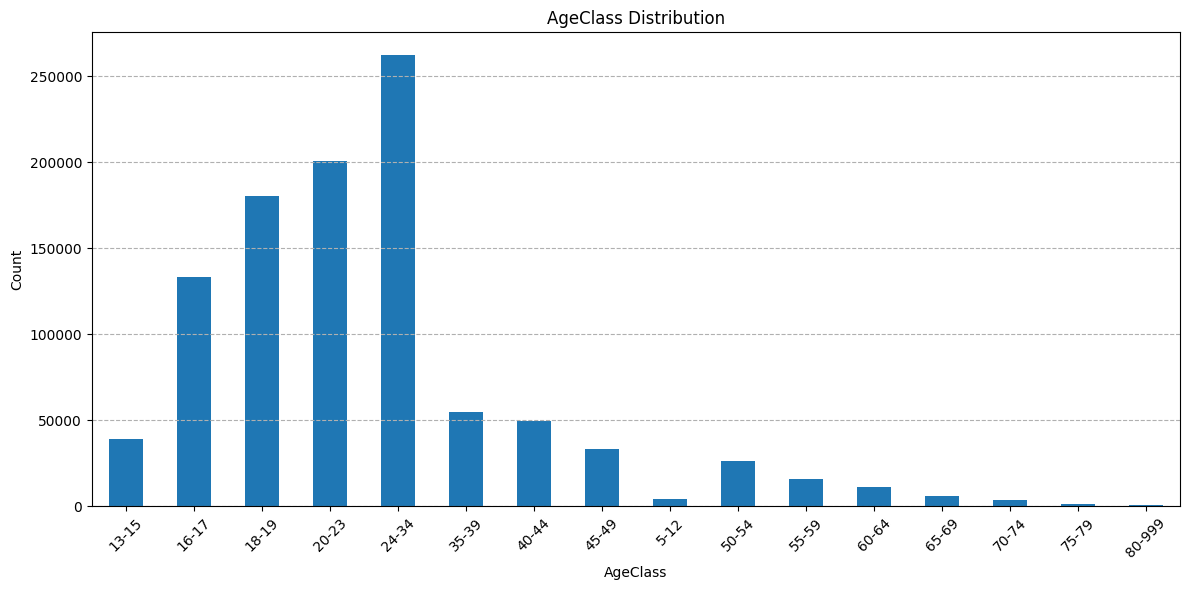

In [9]:
# 연령대 시각화
import matplotlib.pyplot as plt

age_counts = filtered_df["AgeClass"].value_counts().sort_index()  # 연령순 정렬

plt.figure(figsize=(12, 6))
age_counts.plot(kind='bar')

plt.title("AgeClass Distribution")
plt.xlabel("AgeClass")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


In [10]:
# 18 ~ 44 연령대만 추출
target = ['24-34', '20-23', '35-39', '18-19', '40-44']
filtered_df = filtered_df[filtered_df['AgeClass'].isin(target)]

In [11]:
filtered_df

,Sex,AgeClass,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg
0,F,24-34,58.30,80.0,60.0,107.5
1,F,40-44,73.10,105.0,67.5,110.0
3,M,35-39,66.65,137.5,122.5,170.0
4,M,24-34,72.45,90.0,50.0,125.0
7,F,24-34,96.50,100.0,47.5,140.0
...,...,...,...,...,...,...
3043006,F,24-34,128.58,297.5,197.5,230.0
3043007,F,24-34,95.00,260.0,160.0,227.5
3043009,F,24-34,113.22,237.5,195.0,200.0
3043010,F,35-39,110.79,227.5,200.0,190.0


In [12]:
# 무작위 5,000명 추출
    # 남성, 여성 비율 (7:3)
    # 남성 : 3,500명
    # 여성 : 1,500명
male_df = filtered_df[filtered_df["Sex"] == "M"]
female_df = filtered_df[filtered_df["Sex"] == "F"]

male_sample = male_df.sample(n=3500, random_state=42)
female_sample = female_df.sample(n=1500, random_state=42)

sampled_df = pd.concat([male_sample, female_sample]).reset_index(drop=True)


In [13]:
df_copy = sampled_df.copy()

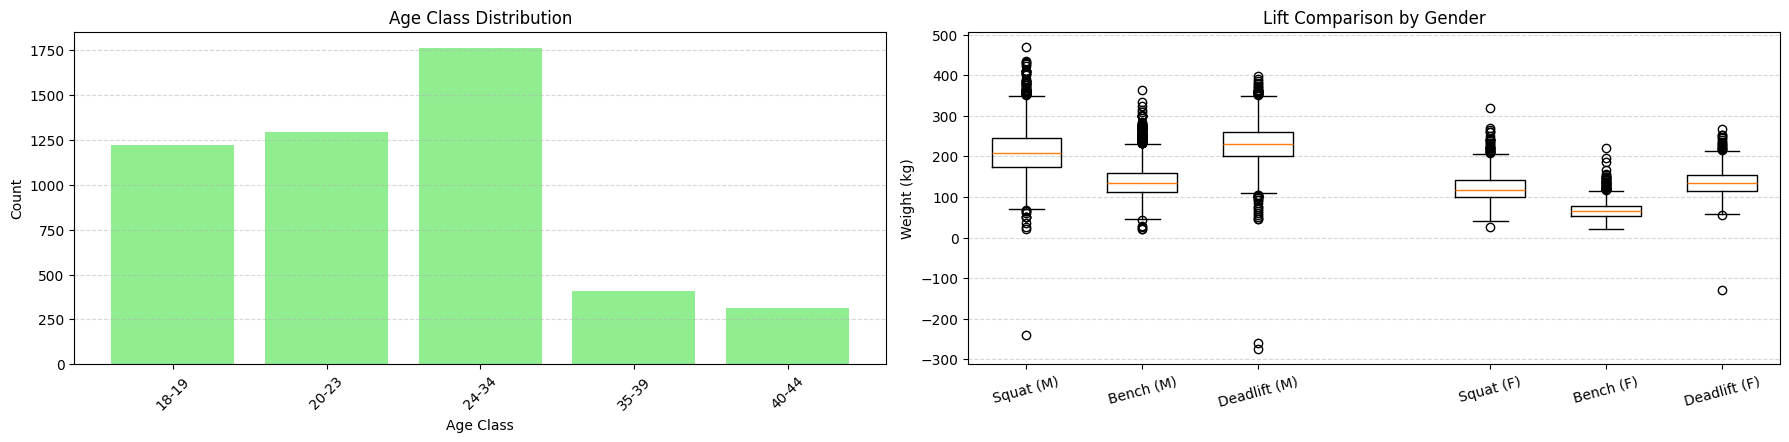

In [14]:
import matplotlib.pyplot as plt

age_counts = sampled_df['AgeClass'].value_counts().sort_index()

lifts = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']
male_lifts = [sampled_df[sampled_df['Sex'] == 'M'][lift].dropna() for lift in lifts]
female_lifts = [sampled_df[sampled_df['Sex'] == 'F'][lift].dropna() for lift in lifts]

plt.figure(figsize=(18, 8))

plt.subplot(2, 2, 1)
plt.bar(age_counts.index, age_counts.values, color='lightgreen')
plt.title('Age Class Distribution')
plt.xlabel('Age Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.subplot(2, 2, 2)
positions = [1, 2, 3, 5, 6, 7]  # male: 1~3, female: 5~7
data = male_lifts + female_lifts
labels = ['Squat (M)', 'Bench (M)', 'Deadlift (M)', 'Squat (F)', 'Bench (F)', 'Deadlift (F)']
plt.boxplot(data, positions=positions, widths=0.6)
plt.xticks(positions, labels, rotation=15)
plt.title('Lift Comparison by Gender')
plt.ylabel('Weight (kg)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


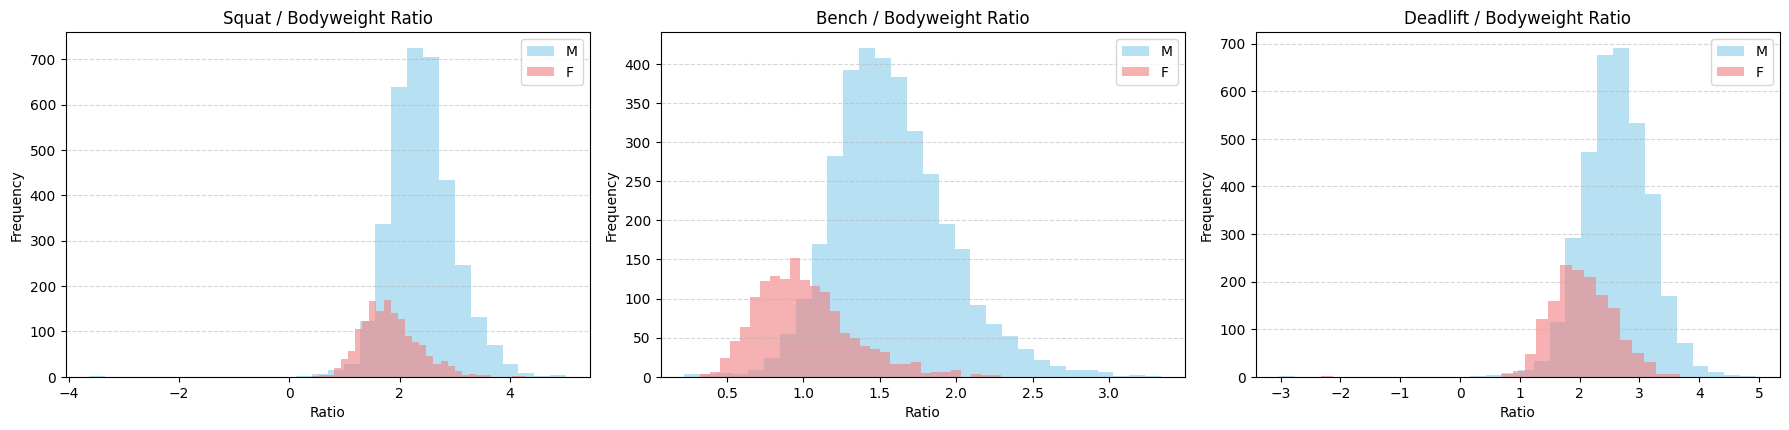

In [15]:
sampled_df['SquatRatio'] = sampled_df['Best3SquatKg'] / sampled_df['BodyweightKg']
sampled_df['BenchRatio'] = sampled_df['Best3BenchKg'] / sampled_df['BodyweightKg']
sampled_df['DeadliftRatio'] = sampled_df['Best3DeadliftKg'] / sampled_df['BodyweightKg']

male_df = sampled_df[sampled_df['Sex'] == 'M']
female_df = sampled_df[sampled_df['Sex'] == 'F']

male_ratios = {
    'Squat': male_df['SquatRatio'],
    'Bench': male_df['BenchRatio'],
    'Deadlift': male_df['DeadliftRatio'],
}

female_ratios = {
    'Squat': female_df['SquatRatio'],
    'Bench': female_df['BenchRatio'],
    'Deadlift': female_df['DeadliftRatio'],
}


plt.figure(figsize=(18, 8))

for i, lift in enumerate(['Squat', 'Bench', 'Deadlift']):
    plt.subplot(2, 3, i + 4)
    plt.hist(male_ratios[lift], bins=30, alpha=0.6, label='M', color='skyblue')
    plt.hist(female_ratios[lift], bins=30, alpha=0.6, label='F', color='lightcoral')
    plt.title(f'{lift} / Bodyweight Ratio')
    plt.xlabel('Ratio')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [16]:
df_copy.to_excel("./dataset/base_dataset.xlsx", index=False)